# Speaker diarization — BalanceCorpus audios

Batch-driver for [`scripts/diarize_speakers.py`](scripts/diarize_speakers.py). Runs `pyannote/speaker-diarization-3.1` (**2 speakers**) on every `.wav` in `audios/` and writes one CSV per file into `diarization/`, **mirroring the audio sub-folder structure**:

```
audios/103_203/103_203_12_..._board.wav   ->   diarization/103_203/103_203_12_..._board.csv
audios/108_208/....wav                     ->   diarization/108_208/....csv
```

Each CSV has columns `time_start, time_end, speaker` (as produced by the script).

In [1]:
# Install dependencies (run once). Restart the kernel afterwards if pyannote was just installed.
%pip install -q "pyannote.audio" soundfile

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ---- HF token: load from .hf_token (or env) and verify access, BEFORE importing the model ----
# If you change the token, RESTART THE KERNEL so this reloads it: diarize_speakers reads
# HF_TOKEN once at import time, so a stale/old token stays cached until a restart.
import os
from pathlib import Path
from huggingface_hub import HfApi
from huggingface_hub.utils import GatedRepoError

if not os.environ.get("HF_TOKEN"):
    for _p in (Path.cwd() / ".hf_token", Path.home() / ".hf_token"):
        if _p.exists():
            os.environ["HF_TOKEN"] = _p.read_text().strip()
            break
if not os.environ.get("HF_TOKEN"):
    raise SystemExit("No HF token. Put a Read token in .hf_token (git-ignored) or set HF_TOKEN, then restart the kernel.")

_api, _tok = HfApi(), os.environ["HF_TOKEN"]
try:
    _user = _api.whoami(token=_tok)["name"]
except Exception as e:
    raise SystemExit(f"HF token INVALID — replace .hf_token and RESTART the kernel. ({type(e).__name__}: {e})")
for _repo in ("pyannote/speaker-diarization-3.1", "pyannote/segmentation-3.0"):
    try:
        _api.auth_check(_repo, token=_tok)
    except GatedRepoError:
        raise SystemExit(f"'{_user}' lacks access to {_repo} — accept the terms at https://huggingface.co/{_repo}")
print(f"✓ HF token OK (user '{_user}'); access to pyannote 3.1 + segmentation-3.0 verified.")

✓ HF token OK (user 'mikub97'); access to pyannote 3.1 + segmentation-3.0 verified.


In [3]:
import sys
from pathlib import Path

# ---- Configuration -------------------------------------------------------
BASE_DIR   = Path.cwd() / ".."                 # .../Datasets/BalanceCorpus
AUDIO_DIR  = BASE_DIR / "audios"
OUTPUT_DIR = BASE_DIR / "diarization"
SCRIPTS_DIR = BASE_DIR 
NUM_SPEAKERS = 2                        # each recording has 2 people
OVERWRITE = False                       # set True to re-run files that already have a CSV

# Make diarize_speakers.py importable and pull in its diarize_file().
sys.path.insert(0, str(SCRIPTS_DIR))
from diarize_speakers import diarize_file

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Audio dir :", AUDIO_DIR)
print("Output dir:", OUTPUT_DIR)

Audio dir : /Users/m11/Documents/codes/TilburgMultiscaleSummerschool2026/Datasets/BalanceCorpus/orangediamond/../audios
Output dir: /Users/m11/Documents/codes/TilburgMultiscaleSummerschool2026/Datasets/BalanceCorpus/orangediamond/../diarization


In [4]:
from tqdm.auto import tqdm

# Every wav, preserving its sub-folder (e.g. 103_203) so the output mirrors it.
wav_files = sorted(AUDIO_DIR.rglob("*.wav"))
print(f"Found {len(wav_files)} wav files")

errors = []
for wav_path in tqdm(wav_files, desc="Diarizing"):
    rel_dir = wav_path.parent.relative_to(AUDIO_DIR)   # e.g. Path('103_203')
    out_dir = OUTPUT_DIR / rel_dir
    out_csv = out_dir / (wav_path.stem + ".csv")

    if out_csv.exists() and not OVERWRITE:
        continue                                        # already processed

    try:
        diarize_file(
            str(wav_path),
            output_dir=str(out_dir),
            output_stem=wav_path.stem,                  # -> <name>.csv, mirrors the wav
            num_speakers=NUM_SPEAKERS,
        )
    except Exception as e:                              # keep going; collect failures
        errors.append((wav_path, repr(e)))

print(f"\nDone. {len(wav_files) - len(errors)} ok, {len(errors)} failed.")
for wav_path, err in errors:
    print("  FAILED", wav_path.name, "->", err)

Found 40 wav files


Diarizing:   0%|          | 0/40 [00:00<?, ?it/s]

/Users/m11/miniconda3/envs/story/lib/python3.12/site-packages/pyannote/audio/core/io.py:48: UserWarning: 
torchcodec is not installed correctly so built-in audio decoding will fail. Solutions are:
* use audio preloaded in-memory as a {'waveform': (channel, time) torch.Tensor, 'sample_rate': int} dictionary;
* fix torchcodec installation. Error message was:

Could not load libtorchcodec. Likely causes:
          1. FFmpeg is not properly installed in your environment. We support
             versions 4, 5, 6 and 7.
          2. The PyTorch version (2.8.0) is not compatible with
             this version of TorchCodec. Refer to the version compatibility
             table:
             https://github.com/pytorch/torchcodec?tab=readme-ov-file#installing-torchcodec.
          3. Another runtime dependency; see exceptions below.
        The following exceptions were raised as we tried to load libtorchcodec:
        
[start of libtorchcodec loading traceback]
FFmpeg version 7: dlopen(/Users/

  [Diarization] Loading: pyannote/speaker-diarization-3.1


/Users/m11/miniconda3/envs/story/lib/python3.12/site-packages/speechbrain/utils/torch_audio_backend.py:57: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  available_backends = torchaudio.list_audio_backends()


...

  [Diarization] Using MPS (Apple Silicon)
  [Diarization] Loading audio via soundfile: /Users/m11/Documents/codes/TilburgMultiscaleSummerschool2026/Datasets/BalanceCorpus/orangediamond/../audios/116_216/116_216_23_1_20250116_102753_doughnut_ground.wav
  [Diarization n_speakers=2] Processing... (this may take a while)
  [Diarization] Saved 6 segments → /Users/m11/Documents/codes/TilburgMultiscaleSummerschool2026/Datasets/BalanceCorpus/orangediamond/../diarization/116_216/116_216_23_1_20250116_102753_doughnut_ground.csv
  [Diarization] Loading: pyannote/speaker-diarization-3.1
  [Diarization] Using MPS (Apple Silicon)
  [Diarization] Loading audio via soundfile: /Users/m11/Documents/codes/TilburgMultiscaleSummerschool2026/Datasets/BalanceCorpus/orangediamond/../audios/116_216/116_216_24_1_20250116_102808_bacon_ground.wav
  [Diarization n_speakers=2] Processing... (this may take a while)
  [Diarization] Saved 6 segments → /Users/m11/Documents/codes/TilburgMultiscaleSummerschool2026/Datase

/Users/m11/miniconda3/envs/story/lib/python3.12/site-packages/pyannote/audio/pipelines/speaker_diarization.py:662: UserWarning: 
The detected number of speakers (1) for waveform is outside
the given bounds [2, 2]. This can happen if the
given audio file is too short to contain 2 or more speakers.
Try to lower the desired minimal number of speakers.

  warnings.warn(


  [Diarization] Using MPS (Apple Silicon)
  [Diarization] Loading audio via soundfile: /Users/m11/Documents/codes/TilburgMultiscaleSummerschool2026/Datasets/BalanceCorpus/orangediamond/../audios/116_216/116_216_35_1_20250116_103333_flannel_ground.wav
  [Diarization n_speakers=2] Processing... (this may take a while)
  [Diarization] Saved 37 segments → /Users/m11/Documents/codes/TilburgMultiscaleSummerschool2026/Datasets/BalanceCorpus/orangediamond/../diarization/116_216/116_216_35_1_20250116_103333_flannel_ground.csv
  [Diarization] Loading: pyannote/speaker-diarization-3.1
  [Diarization] Using MPS (Apple Silicon)
  [Diarization] Loading audio via soundfile: /Users/m11/Documents/codes/TilburgMultiscaleSummerschool2026/Datasets/BalanceCorpus/orangediamond/../audios/116_216/116_216_36_1_20250116_103426_jungle_ground.wav
  [Diarization n_speakers=2] Processing... (this may take a while)
  [Diarization] Saved 13 segments → /Users/m11/Documents/codes/TilburgMultiscaleSummerschool2026/Datas

/Users/m11/miniconda3/envs/story/lib/python3.12/site-packages/pyannote/audio/pipelines/speaker_diarization.py:662: UserWarning: 
The detected number of speakers (1) for waveform is outside
the given bounds [2, 2]. This can happen if the
given audio file is too short to contain 2 or more speakers.
Try to lower the desired minimal number of speakers.

  warnings.warn(


  [Diarization] Using MPS (Apple Silicon)
  [Diarization] Loading audio via soundfile: /Users/m11/Documents/codes/TilburgMultiscaleSummerschool2026/Datasets/BalanceCorpus/orangediamond/../audios/116_216/116_216_41_1_20250116_103635_soda_ground.wav
  [Diarization n_speakers=2] Processing... (this may take a while)
  [Diarization] Saved 21 segments → /Users/m11/Documents/codes/TilburgMultiscaleSummerschool2026/Datasets/BalanceCorpus/orangediamond/../diarization/116_216/116_216_41_1_20250116_103635_soda_ground.csv
  [Diarization] Loading: pyannote/speaker-diarization-3.1
  [Diarization] Using MPS (Apple Silicon)
  [Diarization] Loading audio via soundfile: /Users/m11/Documents/codes/TilburgMultiscaleSummerschool2026/Datasets/BalanceCorpus/orangediamond/../audios/116_216/116_216_42_1_20250116_103705_exam_ground.wav
  [Diarization n_speakers=2] Processing... (this may take a while)
  [Diarization] Saved 8 segments → /Users/m11/Documents/codes/TilburgMultiscaleSummerschool2026/Datasets/Balan

## Quick check

Confirm the outputs landed in the mirrored structure and eyeball one CSV.

In [13]:
import pandas as pd

csvs = sorted(OUTPUT_DIR.rglob("*.csv"))
print(f"{len(csvs)} diarization CSVs under {OUTPUT_DIR}")
for c in csvs[:5]:
    print("  ", c.relative_to(OUTPUT_DIR))

if csvs:
    example = csvs[0]
    print("\nExample:", example.relative_to(OUTPUT_DIR))
    display(pd.read_csv(example))

120 diarization CSVs under /Users/m11/Documents/codes/TilburgMultiscaleSummerschool2026/Datasets/BalanceCorpus/orangediamond/../diarization
   103_203/103_203_12_1_20250113_152455_doughnut_board.csv
   103_203/103_203_13_1_20250113_152513_spinach_board.csv
   103_203/103_203_14_1_20250113_152536_balloon_board.csv
   103_203/103_203_15_1_20250113_152557_bacon_board.csv
   103_203/103_203_16_1_20250113_152613_chlorine_board.csv

Example: 103_203/103_203_12_1_20250113_152455_doughnut_board.csv


,time_start,time_end,speaker
0,1.3303,4.6041,SPEAKER_00
1,5.7010,6.0385,SPEAKER_00
2,6.0385,7.8441,SPEAKER_01
3,7.7428,7.9960,SPEAKER_00
4,7.9960,10.0041,SPEAKER_01
5,11.2360,13.8685,SPEAKER_01
6,14.6616,15.7078,SPEAKER_00
7,15.6066,15.8935,SPEAKER_01
8,15.8935,15.9778,SPEAKER_00
9,16.1635,16.5516,SPEAKER_00


In [14]:
def merge_segments(df):
    """Glue all consecutive same-speaker turns into one turn (no gap limit)."""
    df = df.sort_values("time_start").reset_index(drop=True)

    merged = []
    for r in df.itertuples(index=False):
        if merged and r.speaker == merged[-1]["speaker"]:
            # same speaker as previous turn -> extend it
            merged[-1]["time_end"] = max(merged[-1]["time_end"], r.time_end)
        else:
            merged.append({"time_start": r.time_start,
                           "time_end": r.time_end,
                           "speaker": r.speaker})

    return pd.DataFrame(merged)


120 recordings, threshold = 0.5s


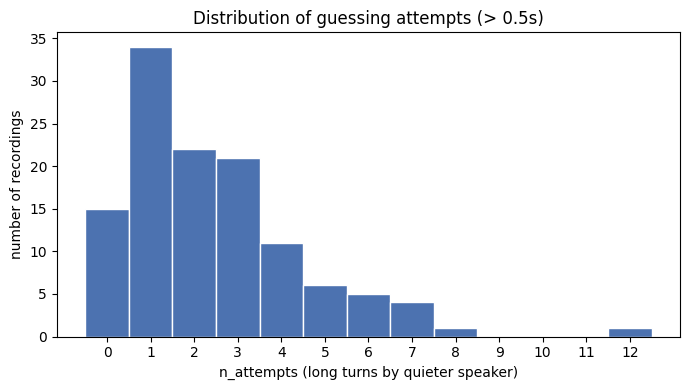

In [15]:
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path.cwd() /".."/ "diarization"   # adjust if needed
MIN_TURN_SEC = 0.5


def guessing_attempts(csv_path, min_turn_sec=MIN_TURN_SEC):
    """Count long turns by the speaker who spoke less in one diarization CSV."""
    df = pd.read_csv(csv_path)
    df["duration"] = df["time_end"] - df["time_start"]

    # Total speaking time per speaker -> the quieter one is the guesser.
    totals = df.groupby("speaker")["duration"].sum()
    quiet_speaker = totals.idxmin()

    quiet_turns = df[df["speaker"] == quiet_speaker]
    n_attempts = int((quiet_turns["duration"] > min_turn_sec).sum())

    return {
        "pair": csv_path.parent.name,
        "file": csv_path.stem,
        "quiet_speaker": quiet_speaker,
        "quiet_total_sec": round(float(totals.min()), 2),
        "loud_total_sec": round(float(totals.max()), 2),
        "n_attempts": n_attempts,
    }


csvs = sorted(OUTPUT_DIR.rglob("*.csv"))
attempts = pd.DataFrame([guessing_attempts(c) for c in csvs])
print(f"{len(attempts)} recordings, threshold = {MIN_TURN_SEC}s")



import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))

# integer-aligned bins so each count sits in its own bar
bins = range(attempts["n_attempts"].min(), attempts["n_attempts"].max() + 2)
ax.hist(attempts["n_attempts"], bins=bins, align="left",
        edgecolor="white", color="#4C72B0")

ax.set_xlabel("n_attempts (long turns by quieter speaker)")
ax.set_ylabel("number of recordings")
ax.set_title(f"Distribution of guessing attempts (> {MIN_TURN_SEC}s)")
ax.set_xticks(list(bins)[:-1])
plt.tight_layout()
plt.show()




In [16]:
!pip install faster-whisper


40

In [26]:
from pathlib import Path
import numpy as np
import pandas as pd
import soundfile as sf
import torch, torchaudio
from faster_whisper import WhisperModel

BASE_DIR      = Path.cwd()/".."                 # .../Datasets/BalanceCorpus
AUDIO_DIR     = BASE_DIR / "audios"
DIA_DIR       = BASE_DIR / "diarization"
TRANSCRIPT_DIR = BASE_DIR / "transcripts"
LANGUAGE      = "en"                        # set None to auto-detect
TARGET_SR     = 16000                       # whisper expects 16 kHz mono

# Load the ASR model once. "small" is a good speed/quality tradeoff; use "base" for faster.
model = WhisperModel("small", device="cpu", compute_type="int8")


def transcribe_segment(audio, sr, start, end):
    """Transcribe one [start, end] slice of a mono 16 kHz waveform."""
    seg = audio[int(start * sr): int(end * sr)]
    if seg.size == 0:
        return ""
    segments, _ = model.transcribe(seg, language=LANGUAGE, beam_size=1, vad_filter=False)
    return " ".join(s.text.strip() for s in segments).strip()


def transcribe_file(csv_path):
    """Merge same-speaker turns, transcribe each, then save."""
    rel = csv_path.relative_to(DIA_DIR).with_suffix(".wav")
    wav_path = AUDIO_DIR / rel
    if not wav_path.exists():
        raise FileNotFoundError(wav_path)

    # Load wav -> mono -> 16 kHz float32.
    data, sr = sf.read(str(wav_path), dtype="float32")
    wav = torch.from_numpy(data)
    if wav.ndim > 1:
        wav = wav.mean(dim=1)                       # stereo -> mono
    if sr != TARGET_SR:
        wav = torchaudio.functional.resample(wav, sr, TARGET_SR)
    audio = wav.numpy()

    df = pd.read_csv(csv_path)
    df = merge_segments(df)                          # glue same-speaker turns
    df["text"] = [
        transcribe_segment(audio, TARGET_SR, r.time_start, r.time_end)
        for r in df.itertuples()
    ]

    # --- merge before saving ---
    out_path = TRANSCRIPT_DIR / csv_path.relative_to(DIA_DIR)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(out_path, index=False)
    return df



csvs = sorted(DIA_DIR.rglob("*.csv"))
for csv_path in csvs[-40:]:
    transcribe_file(csv_path)
    print("done", csv_path.relative_to(DIA_DIR))


done 116_216/116_216_12_1_20250116_102514_butter_board.csv
done 116_216/116_216_13_1_20250116_102527_traffic_board.csv
done 116_216/116_216_14_1_20250116_102556_picture_board.csv
done 116_216/116_216_15_1_20250116_102602_siren_board.csv
done 116_216/116_216_16_1_20250116_102611_pasta_board.csv
done 116_216/116_216_17_1_20250116_102622_yellow_board.csv
done 116_216/116_216_18_1_20250116_102638_hunger_board.csv
done 116_216/116_216_19_1_20250116_102654_leather_board.csv
done 116_216/116_216_20_1_20250116_102710_pillow_board.csv
done 116_216/116_216_21_1_20250116_102716_muscle_board.csv
done 116_216/116_216_23_1_20250116_102753_doughnut_ground.csv
done 116_216/116_216_24_1_20250116_102808_bacon_ground.csv
done 116_216/116_216_25_1_20250116_102832_puppy_ground.csv
done 116_216/116_216_26_1_20250116_102855_sugar_ground.csv
done 116_216/116_216_27_1_20250116_102911_zipper_ground.csv
done 116_216/116_216_28_1_20250116_102950_cologne_ground.csv
done 116_216/116_216_29_1_20250116_103005_hamster

## Manual work here....

## Step 4 — clean transcripts: drop silent guesser turns, then trim to the guess

Two cleanups, in place in `TRANSCRIPT_DIR`:

1. **Drop the guesser's silent turns** — the quieter speaker (least total speaking time) is the
   guesser; turns the diarizer marked for them but the ASR left empty are not real guesses.
2. **Trim to the correct guess** — the first remaining turn containing the target word (from the
   filename, e.g. `doughnut`) is the winning guess (`is_correct_guess = True`); later turns are
   dropped. Matching tolerates plurals and ASR spelling variants (`doughnut` ≈ `donuts`).

In [ ]:
import re, difflib

# ---- Step 4 — clean transcripts: drop silent guesser turns, then trim to the guess ----

def target_word(path):
    return path.stem.split("_")[-2].lower()          # token before board/ground

def _tokens(text):
    return re.findall(r"[a-z']+", str(text).lower())

def _matches(target, tok):
    if tok == target:
        return True
    if tok.rstrip("s") == target.rstrip("s") and abs(len(tok) - len(target)) <= 2:
        return True                                   # plural/singular
    r = difflib.SequenceMatcher(None, target, tok).ratio()
    return r >= 0.80 or (r >= 0.70 and tok[:1] == target[:1] and abs(len(tok) - len(target)) <= 3)

def guess_index(df, target):
    for i, txt in enumerate(df["text"]):
        if any(_matches(target, t) for t in _tokens(txt)):
            return i
    return None

def clean_transcript(path):
    df = pd.read_csv(path)
    df["text"] = df["text"].fillna("").astype(str)

    # The quieter speaker (least total speaking time) is the guesser.
    totals = (df["time_end"] - df["time_start"]).groupby(df["speaker"]).sum()
    guesser = totals.idxmin()

    # 1. Drop the guesser's silent turns (diarized but no transcribed words) — not real guesses.
    silent = (df["speaker"] == guesser) & (df["text"].str.strip() == "")
    n_silent = int(silent.sum())
    df = df[~silent].reset_index(drop=True)

    # 2. Trim to the correct guess: first remaining turn containing the target word.
    tgt = target_word(path)
    idx = guess_index(df, tgt)
    df["is_correct_guess"] = False
    if idx is not None:
        df.loc[idx, "is_correct_guess"] = True
        df = df.iloc[: idx + 1]

    df.to_csv(path, index=False)
    return {"trial": path.stem, "target": tgt, "guesser": guesser,
            "silent_dropped": n_silent, "guessed": idx is not None, "turns_kept": len(df)}

cleaned = pd.DataFrame(
    clean_transcript(f)
    for f in sorted(TRANSCRIPT_DIR.rglob("*.csv"))
    if not f.name.startswith("_")                      # skip stale '_'-prefixed duplicates
)
print(f"{int(cleaned['guessed'].sum())}/{len(cleaned)} transcripts trimmed to the guess; "
      f"dropped {int(cleaned['silent_dropped'].sum())} silent guesser turns total.")
_missed = cleaned[~cleaned.guessed]
if len(_missed):
    print("\nTarget word not found (kept whole) — inspect ASR/wording:")
    print(_missed[["trial", "target"]].to_string(index=False))
cleaned.head()

3/3 transcripts trimmed to the guess; dropped 3 silent guesser turns total.


,trial,target,guesser,silent_dropped,guessed,turns_kept
0,103_203_12_1_20250113_152455_doughnut_board,doughnut,SPEAKER_00,0,True,5
1,103_203_13_1_20250113_152513_spinach_board,spinach,SPEAKER_01,2,True,5
2,103_203_14_1_20250113_152536_balloon_board,balloon,SPEAKER_00,1,True,6


## Distribution of guessing attempts

After the cleaning above (silent guesser turns dropped, trimmed to the correct guess), count the
guesser's turns per recording — each is a guessing attempt — and show the distribution across all
recordings.

80 recordings — guessing attempts: mean 2.6, median 1, range 1–13


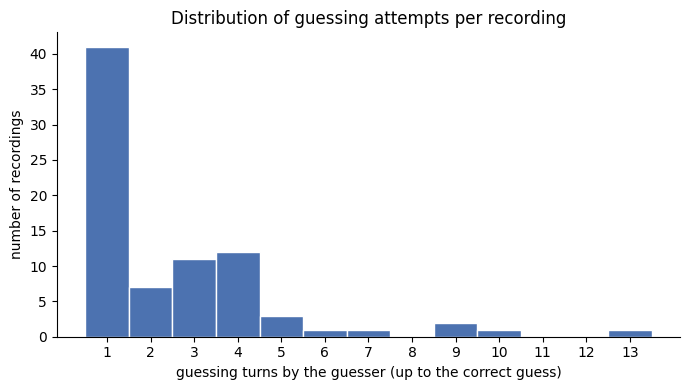

In [ ]:
import matplotlib.pyplot as plt

# ---- Distribution of guessing attempts (after the cleaning above) ----------

def n_guess_attempts(path):
    """Number of guesser turns up to & incl. the correct guess = guessing attempts."""
    df = pd.read_csv(path)
    if df.empty:
        return None
    if "is_correct_guess" in df.columns and df["is_correct_guess"].any():
        guesser = df.loc[df["is_correct_guess"], "speaker"].iloc[0]     # who said the word
    else:
        totals = (df["time_end"] - df["time_start"]).groupby(df["speaker"]).sum()
        guesser = totals.idxmin()
    return int((df["speaker"] == guesser).sum())

attempts = pd.Series(
    n
    for f in sorted(TRANSCRIPT_DIR.rglob("*.csv")) if not f.name.startswith("_")
    for n in [n_guess_attempts(f)] if n is not None
)
print(f"{len(attempts)} recordings — guessing attempts: mean {attempts.mean():.1f}, "
      f"median {attempts.median():.0f}, range {attempts.min()}–{attempts.max()}")

fig, ax = plt.subplots(figsize=(7, 4))
bins = range(int(attempts.min()), int(attempts.max()) + 2)
ax.hist(attempts, bins=bins, align="left", edgecolor="white", color="#4C72B0")
ax.set_xlabel("guessing turns by the guesser (up to the correct guess)")
ax.set_ylabel("number of recordings")
ax.set_title("Distribution of guessing attempts per recording")
ax.set_xticks(list(bins)[:-1])
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()